In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
df=pd.read_csv("/content/hospital_readmissions_30k.csv")

In [90]:
#Data exploration
#Data sample - first five rows
df.head()

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No


Insight -
*   Continous numerical features - patient_id, age, blood_pressure, cholesterol,bmi,medication_count,length_of_stay

*   Categorical Features - gender, diabetes, hypertension, discharge_destination,readmitted_30_days

*   Target feature - readmitted_30_days


In [91]:
#Shape of data
df.shape

(30000, 12)

Hence we have 12 columns including target feature and 30,000 records

In [92]:
#Data info showing null values if present and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30000 non-null  int64  
 1   age                    30000 non-null  int64  
 2   gender                 30000 non-null  object 
 3   blood_pressure         30000 non-null  object 
 4   cholesterol            30000 non-null  int64  
 5   bmi                    30000 non-null  float64
 6   diabetes               30000 non-null  object 
 7   hypertension           30000 non-null  object 
 8   medication_count       30000 non-null  int64  
 9   length_of_stay         30000 non-null  int64  
 10  discharge_destination  30000 non-null  object 
 11  readmitted_30_days     30000 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 2.7+ MB


In [93]:
#Statistical Summary of data
df.describe()

,patient_id,age,cholesterol,bmi,medication_count,length_of_stay
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,53.884233,225.260400,28.946263,5.012267,5.502900
std,8660.398374,21.056485,43.585671,6.348204,3.166383,2.867298
min,1.000000,18.000000,150.000000,18.000000,0.000000,1.000000
25%,7500.750000,36.000000,188.000000,23.400000,2.000000,3.000000
50%,15000.500000,54.000000,225.000000,28.900000,5.000000,5.000000
75%,22500.250000,72.000000,263.000000,34.500000,8.000000,8.000000
max,30000.000000,90.000000,300.000000,40.000000,10.000000,10.000000


In [94]:
#Columns list
print("Columns present in dataset:",df.columns)

Columns present in dataset: Index(['patient_id', 'age', 'gender', 'blood_pressure', 'cholesterol', 'bmi',
       'diabetes', 'hypertension', 'medication_count', 'length_of_stay',
       'discharge_destination', 'readmitted_30_days'],
      dtype='object')


In [95]:
#Categorical columns unique values
print("Categories of gender feature : ",df['gender'].value_counts())
print("Categories of diabetes feature : ",df['diabetes'].value_counts())
print("Categories of hypertension feature : ",df['hypertension'].value_counts())
print("Categories of discharge-destination feature : ",df['discharge_destination'].value_counts())
print("Categories of readmission in 30 days feature : ",df['readmitted_30_days'].value_counts())


Categories of gender feature :  gender
Male      10097
Other     10024
Female     9879
Name: count, dtype: int64
Categories of diabetes feature :  diabetes
No     15051
Yes    14949
Name: count, dtype: int64
Categories of hypertension feature :  hypertension
No     15022
Yes    14978
Name: count, dtype: int64
Categories of discharge-destination feature :  discharge_destination
Home                20877
Rehab                6096
Nursing_Facility     3027
Name: count, dtype: int64
Categories of readmission in 30 days feature :  readmitted_30_days
No     26326
Yes     3674
Name: count, dtype: int64


In [96]:
#Missing Value check
df.isnull().sum()

,0
patient_id,0
age,0
gender,0
blood_pressure,0
cholesterol,0
bmi,0
diabetes,0
hypertension,0
medication_count,0
length_of_stay,0


No null values are present

In [97]:
df.duplicated().sum()

np.int64(0)

In [98]:
#Since blood pressure is in 120/80 format , string object but it is a continuous numerical feature , we should split it into its two parts 120(systolic BP) and 80 (diastolic BP)
df[['systolic_BP','diastolic_BP']]=df['blood_pressure'].str.split('/',expand=True)
# df.head()
df['systolic_BP']=pd.to_numeric(df['systolic_BP'])
df['diastolic_BP']=pd.to_numeric(df['diastolic_BP'])
df.drop('blood_pressure',axis=1,inplace=True)
df.head()

,patient_id,age,gender,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days,systolic_BP,diastolic_BP
0,1,74,Other,240,31.5,Yes,No,5,1,Nursing_Facility,Yes,130,72
1,2,46,Female,292,36.3,No,No,4,3,Nursing_Facility,No,120,92
2,3,89,Other,153,30.3,No,Yes,1,1,Home,No,135,78
3,4,84,Female,153,31.5,No,Yes,3,10,Home,No,123,80
4,5,32,Other,205,18.4,No,Yes,6,4,Nursing_Facility,No,135,84


No duplicates present

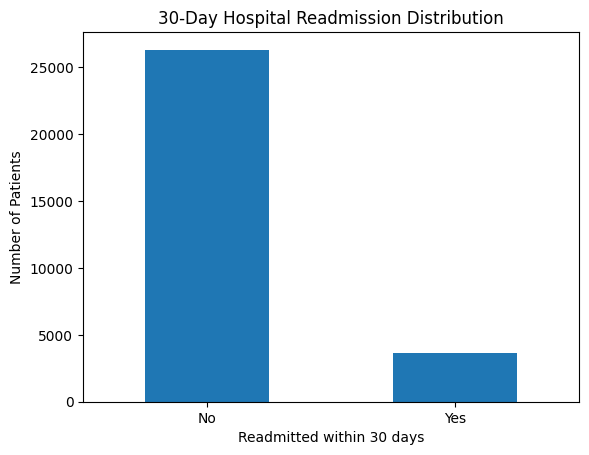

In [99]:
#Visualizing target variable
df['readmitted_30_days'].value_counts().plot(kind='bar')

plt.title("30-Day Hospital Readmission Distribution")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.show()

Frequency of not readmitting is much higher

In [100]:
numerical_cols = [
    'age',
    'cholesterol',
    'bmi',
    'medication_count',
    'length_of_stay',
    'systolic_BP',
    'diastolic_BP'
]
categorical_features = [
    'gender',
    'diabetes',
    'hypertension',
    'discharge_destination'
]

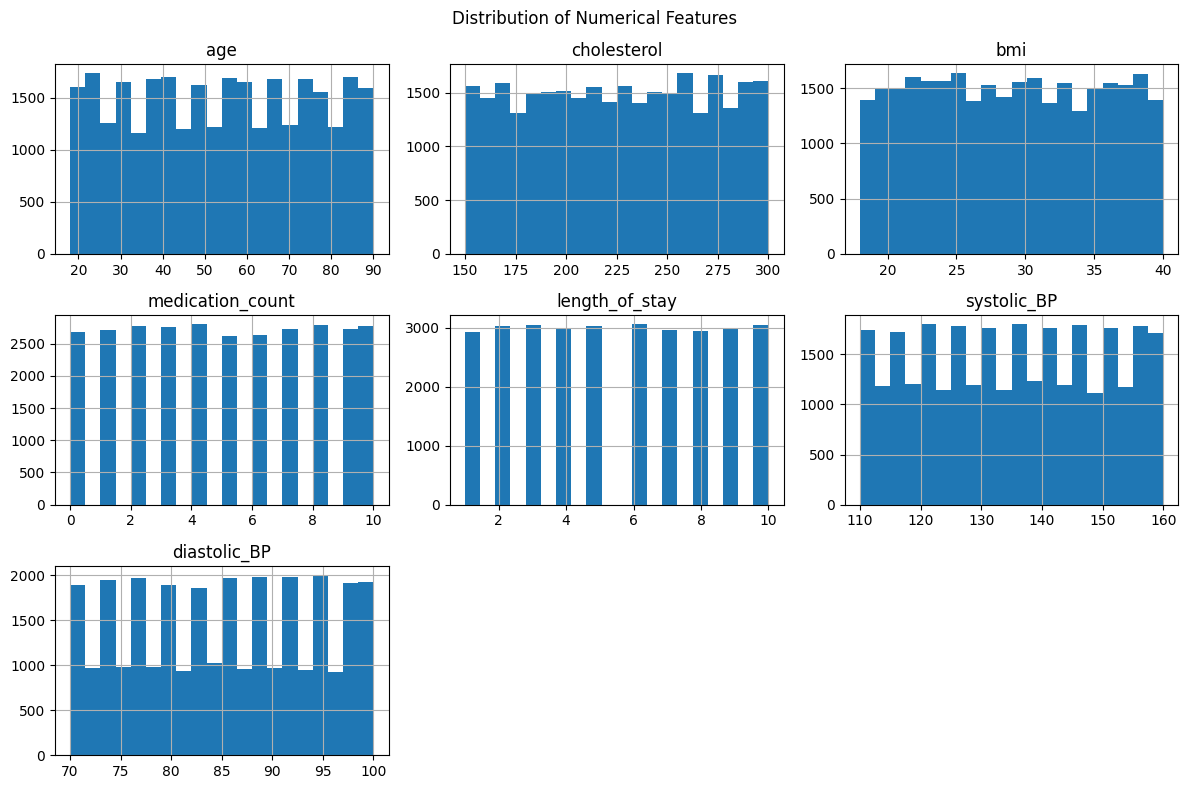

In [136]:
df[numerical_cols].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

In [101]:
#Dropping Patient_id - since it won't be useful feature
df=df.drop('patient_id',axis=1)
df.sample(1)

,age,gender,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days,systolic_BP,diastolic_BP
2435,69,Female,181,33.4,Yes,No,9,6,Home,No,113,85


In [102]:
X=df.drop('readmitted_30_days',axis=1)
y=df['readmitted_30_days']

In [103]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (30000, 11)
Target shape: (30000,)


In [104]:
print("Features:")
print(X.head())

print("Target:")
print(y.head())

Features:
   age  gender  cholesterol   bmi diabetes hypertension  medication_count  \
0   74   Other          240  31.5      Yes           No                 5   
1   46  Female          292  36.3       No           No                 4   
2   89   Other          153  30.3       No          Yes                 1   
3   84  Female          153  31.5       No          Yes                 3   
4   32   Other          205  18.4       No          Yes                 6   

   length_of_stay discharge_destination  systolic_BP  diastolic_BP  
0               1      Nursing_Facility          130            72  
1               3      Nursing_Facility          120            92  
2               1                  Home          135            78  
3              10                  Home          123            80  
4               4      Nursing_Facility          135            84  
Target:
0    Yes
1     No
2     No
3     No
4     No
Name: readmitted_30_days, dtype: object


In [105]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [106]:
X_train.shape

(24000, 11)

In [107]:
X_test.shape

(6000, 11)

In [108]:
y_train.shape

(24000,)

In [109]:
y_test.shape

(6000,)

In [110]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test=label_encoder.transform(y_test)


In [111]:
label_encoder.classes_


array(['No', 'Yes'], dtype=object)

So No is 0 and yes is 1

In [112]:
#Encoding categorical features
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_train_cat = encoder.fit_transform(
    X_train[categorical_features]
)

X_test_cat = encoder.transform(
    X_test[categorical_features]
)

In [113]:
encoded_columns = encoder.get_feature_names_out(
    categorical_features
)

X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=encoded_columns,
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=encoded_columns,
    index=X_test.index
)

In [114]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test_num = scaler.transform(
    X_test[numerical_cols]
)

In [115]:
X_train_num = pd.DataFrame(
    X_train_num,
    columns=numerical_cols,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    X_test_num,
    columns=numerical_cols,
    index=X_test.index
)

In [116]:
#Merging categorical and numerical features
X_train_processed=pd.concat([X_train_num,X_train_cat],axis=1)
X_test_processed=pd.concat([X_test_num,X_test_cat],axis=1)

In [117]:
X_train_processed.head()

,age,cholesterol,bmi,medication_count,length_of_stay,systolic_BP,diastolic_BP,gender_Female,gender_Male,gender_Other,diabetes_No,diabetes_Yes,hypertension_No,hypertension_Yes,discharge_destination_Home,discharge_destination_Nursing_Facility,discharge_destination_Rehab
7445,-1.416484,1.025236,-0.862083,-1.271782,-0.525267,0.953601,-0.898603,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
28092,-1.558871,0.475798,-1.350191,-1.587514,0.171085,0.817236,-1.458623,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
6664,0.292163,0.636050,0.901405,-0.324586,1.563790,1.158150,0.893460,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
10741,-0.846935,-1.218305,1.169077,0.622611,0.171085,-1.500978,-0.786599,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
86,0.814249,-1.561704,0.917150,0.622611,-0.525267,1.430881,0.445444,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0


In [118]:
#Training logistic regression model with l2 regularization

In [119]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    penalty='l2',
    max_iter=1000,
    random_state=42,

)

logistic_model.fit(
    X_train_processed,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [120]:
# Predicted class
y_pred = logistic_model.predict(X_test_processed)

In [121]:
#CONFUSION MATRIX
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[5265,    0],
       [ 735,    0]])

The confusion matrix shows that the model classified all 6,000 test patients as not readmitted. It correctly identified 5,265 non-readmitted patients (TN), but failed to identify any of the 735 readmitted patients (TP = 0), resulting in 735 false negatives

In [122]:
y_prob = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

In [123]:
from sklearn.metrics import roc_auc_score

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.5638128831779625


Since ROC AUC CURVE SCORE IS NEAR TO 0.5, IT IS ONLY RANDOMLY GUESSING

In [124]:
#Let us check if our results are better for different l2 lambda values- c is inverse of lambda

C_values = [0.001, 0.01, 0.1, 1, 10, 100]

for C in C_values:

    model = LogisticRegression(
        penalty='l2',
        C=C,
        max_iter=1000,
        random_state=42
    )

    # Train
    model.fit(X_train_processed, y_train)

    # Probability of Yes/readmission
    y_probs = model.predict_proba(X_test_processed)[:, 1]

    # ROC-AUC
    auc = roc_auc_score(y_test, y_probs)

    print(f"C = {C:<6} | ROC-AUC = {auc:.4f}")

C = 0.001  | ROC-AUC = 0.5631
C = 0.01   | ROC-AUC = 0.5637
C = 0.1    | ROC-AUC = 0.5638
C = 1      | ROC-AUC = 0.5638
C = 10     | ROC-AUC = 0.5638
C = 100    | ROC-AUC = 0.5638


So we can see changing C barely gives us any change in roc auc curve score

In [125]:
from sklearn.metrics import precision_score, recall_score,f1_score,accuracy_score

thresholds = [0.10, 0.12, 0.14, 0.16, 0.18, 0.20, 0.22, 0.25,0.28,0.30, 0.34,0.38,0.42,0.46,0.48,0.50]

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )
    f1=f1_score(y_test,y_pred_threshold,zero_division=0)

    print(f"Threshold: {threshold}")
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1 SCORE : {f1 :.3f}")
    print("----------------------------------------")


Threshold: 0.1
TN: 1990, FP: 3275, FN: 231, TP: 504
Precision: 0.133
Recall: 0.686
F1 SCORE : 0.223
----------------------------------------
Threshold: 0.12
TN: 3584, FP: 1681, FN: 430, TP: 305
Precision: 0.154
Recall: 0.415
F1 SCORE : 0.224
----------------------------------------
Threshold: 0.14
TN: 3783, FP: 1482, FN: 446, TP: 289
Precision: 0.163
Recall: 0.393
F1 SCORE : 0.231
----------------------------------------
Threshold: 0.16
TN: 4113, FP: 1152, FN: 480, TP: 255
Precision: 0.181
Recall: 0.347
F1 SCORE : 0.238
----------------------------------------
Threshold: 0.18
TN: 4669, FP: 596, FN: 598, TP: 137
Precision: 0.187
Recall: 0.186
F1 SCORE : 0.187
----------------------------------------
Threshold: 0.2
TN: 5060, FP: 205, FN: 698, TP: 37
Precision: 0.153
Recall: 0.050
F1 SCORE : 0.076
----------------------------------------
Threshold: 0.22
TN: 5256, FP: 9, FN: 735, TP: 0
Precision: 0.000
Recall: 0.000
F1 SCORE : 0.000
----------------------------------------
Threshold: 0.25




*   So we can see after 0.2 we are getting precision and recall as zero so our threshold should be less than equal to 0.2
*   Next we can see at very low threshold,say 0.1, the false positives are at high rate , that is the model is detecting , patients being readmitted as yes , for more patients than actual
*   For a threshold of 0.2 we see , false positives decreased but recall is only 0.05% which is not great
*   Between 0.1 and 0.2 , we see 0.16 has the highest F1 score , i.e most suitable tradeoff between precision and recall, sofor final model we will use 0.16 as threshold





Clinical Insight

*   In this application, false negatives are clinically important because they represent patients who are actually readmitted but are not identified as high-risk by the model. Missing such patients could result in missed opportunities for additional monitoring or follow-up care.

*   False positives, on the other hand, may result in unnecessary allocation of healthcare resources. Therefore, threshold selection involves a trade-off between reducing false negatives and limiting false positives.




In [126]:
#Final regression model
logistic_model_final = LogisticRegression(
    penalty='l2',
    C=1,
    max_iter=1000,
    random_state=42
)

logistic_model_final.fit(X_train_processed, y_train)

LogisticRegression(C=1, max_iter=1000, random_state=42)

In [127]:
y_prob_final=logistic_model_final.predict_proba(X_test_processed)[:,1]


In [128]:
#we got the probabilities now , we apply our selected threshold to calculated predicted values of y
threshold = 0.16
y_pred_final = (y_prob >= threshold).astype(int)

In [130]:
accuracy = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final, zero_division=0)
recall = recall_score(y_test, y_pred_final, zero_division=0)
f1 = f1_score(y_test, y_pred_final, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob_final)
print("Accuracy : ",accuracy)
print("Precision : ",precision)
print("Recall : ",recall)
print("F1 Score : ",f1)
print("ROC AUC SCORE : ",roc_auc)


Accuracy :  0.728
Precision :  0.1812366737739872
Recall :  0.3469387755102041
F1 Score :  0.23809523809523808
ROC AUC SCORE :  0.5638128831779625


In [131]:
cm = confusion_matrix(y_test, y_pred_final)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4113 1152]
 [ 480  255]]


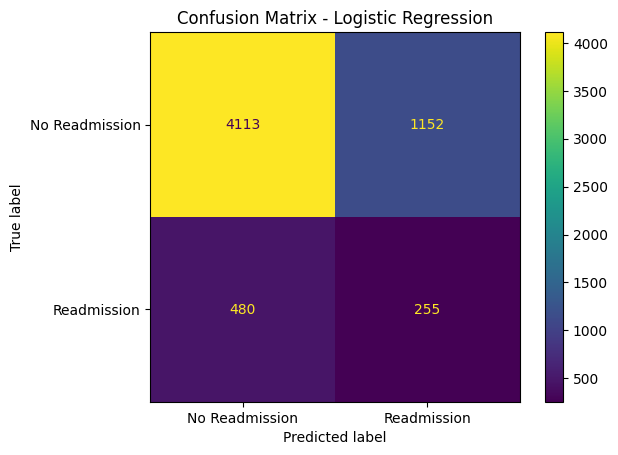

In [134]:
from sklearn.metrics import ConfusionMatrixDisplay
disp_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Readmission', 'Readmission']
)

disp_cm.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

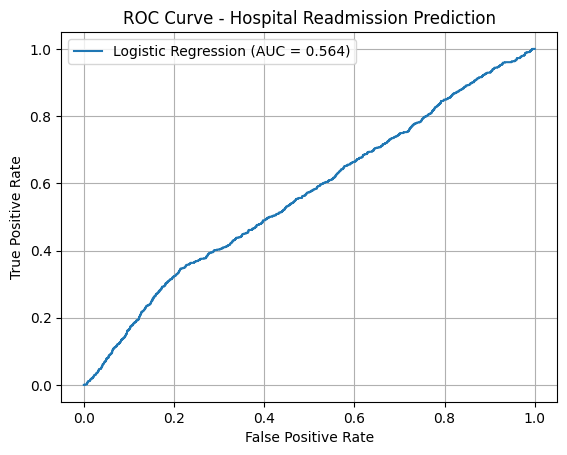

In [135]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)
plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hospital Readmission Prediction")
plt.legend()
plt.grid()
plt.show()

In [133]:
from sklearn.metrics import classification_report
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_final,
    target_names=['No Readmission', 'Readmission'],
    zero_division=0
))

Classification Report:
                precision    recall  f1-score   support

No Readmission       0.90      0.78      0.83      5265
   Readmission       0.18      0.35      0.24       735

      accuracy                           0.73      6000
     macro avg       0.54      0.56      0.54      6000
  weighted avg       0.81      0.73      0.76      6000



# Final insight
The logistic regression model demonstrates weak predictive discrimination on this synthetic dataset. Threshold adjustment can change the balance between false positives and false negatives, but it does not improve the underlying ROC-AUC of the model.


# Clinical Insight

In this application, false negatives are clinically important because they represent patients who are actually readmitted but are not identified as high-risk by the model. Missing such patients could result in missed opportunities for additional monitoring or follow-up care. False positives, on the other hand, may result in unnecessary allocation of healthcare resources. Therefore, threshold selection involves a trade-off between reducing false negatives and limiting false positives.